In [3]:
import pandas as pd
from prophet import Prophet

In [4]:
df = pd.read_csv('./data/AAPL_2023-09-04.csv')
df = df[["Date", "Close"]]
df.columns = ["ds", "y"]
print(df)

              ds           y
0     2017-01-03   29.037500
1     2017-01-04   29.004999
2     2017-01-05   29.152500
3     2017-01-06   29.477501
4     2017-01-09   29.747499
...          ...         ...
1673  2023-08-28  180.190002
1674  2023-08-29  184.119995
1675  2023-08-30  187.649994
1676  2023-08-31  187.869995
1677  2023-09-01  189.460007

[1678 rows x 2 columns]


In [5]:
prophet = Prophet()
prophet.fit(df)

15:21:48 - cmdstanpy - INFO - Chain [1] start processing
15:21:49 - cmdstanpy - INFO - Chain [1] done processing


Now lets make predictions . The make_future_dataframe method in prophet model has a parameter names as 'periods'
, we can use it to set the amount of time we need to make predictions. Now lets make predictions for the next
365 days 

In [6]:
future = prophet.make_future_dataframe(periods=365)
print(future)

             ds
0    2017-01-03
1    2017-01-04
2    2017-01-05
3    2017-01-06
4    2017-01-09
...         ...
2038 2024-08-27
2039 2024-08-28
2040 2024-08-29
2041 2024-08-30
2042 2024-08-31

[2043 rows x 1 columns]


In [7]:
forecast = prophet.predict(future)
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(200)

,ds,yhat,yhat_lower,yhat_upper
1843,2024-02-14,180.357776,167.568046,192.608784
1844,2024-02-15,180.137933,167.672487,192.437400
1845,2024-02-16,179.869873,167.345690,191.922099
1846,2024-02-17,177.237635,164.902713,189.265898
1847,2024-02-18,177.030002,164.134330,189.055647
...,...,...,...,...
2038,2024-08-27,195.513102,171.988463,218.604649
2039,2024-08-28,195.552029,170.015057,218.709983
2040,2024-08-29,195.393664,171.681244,218.048231
2041,2024-08-30,195.187078,170.167404,218.584716


Now lets plot our predictions:

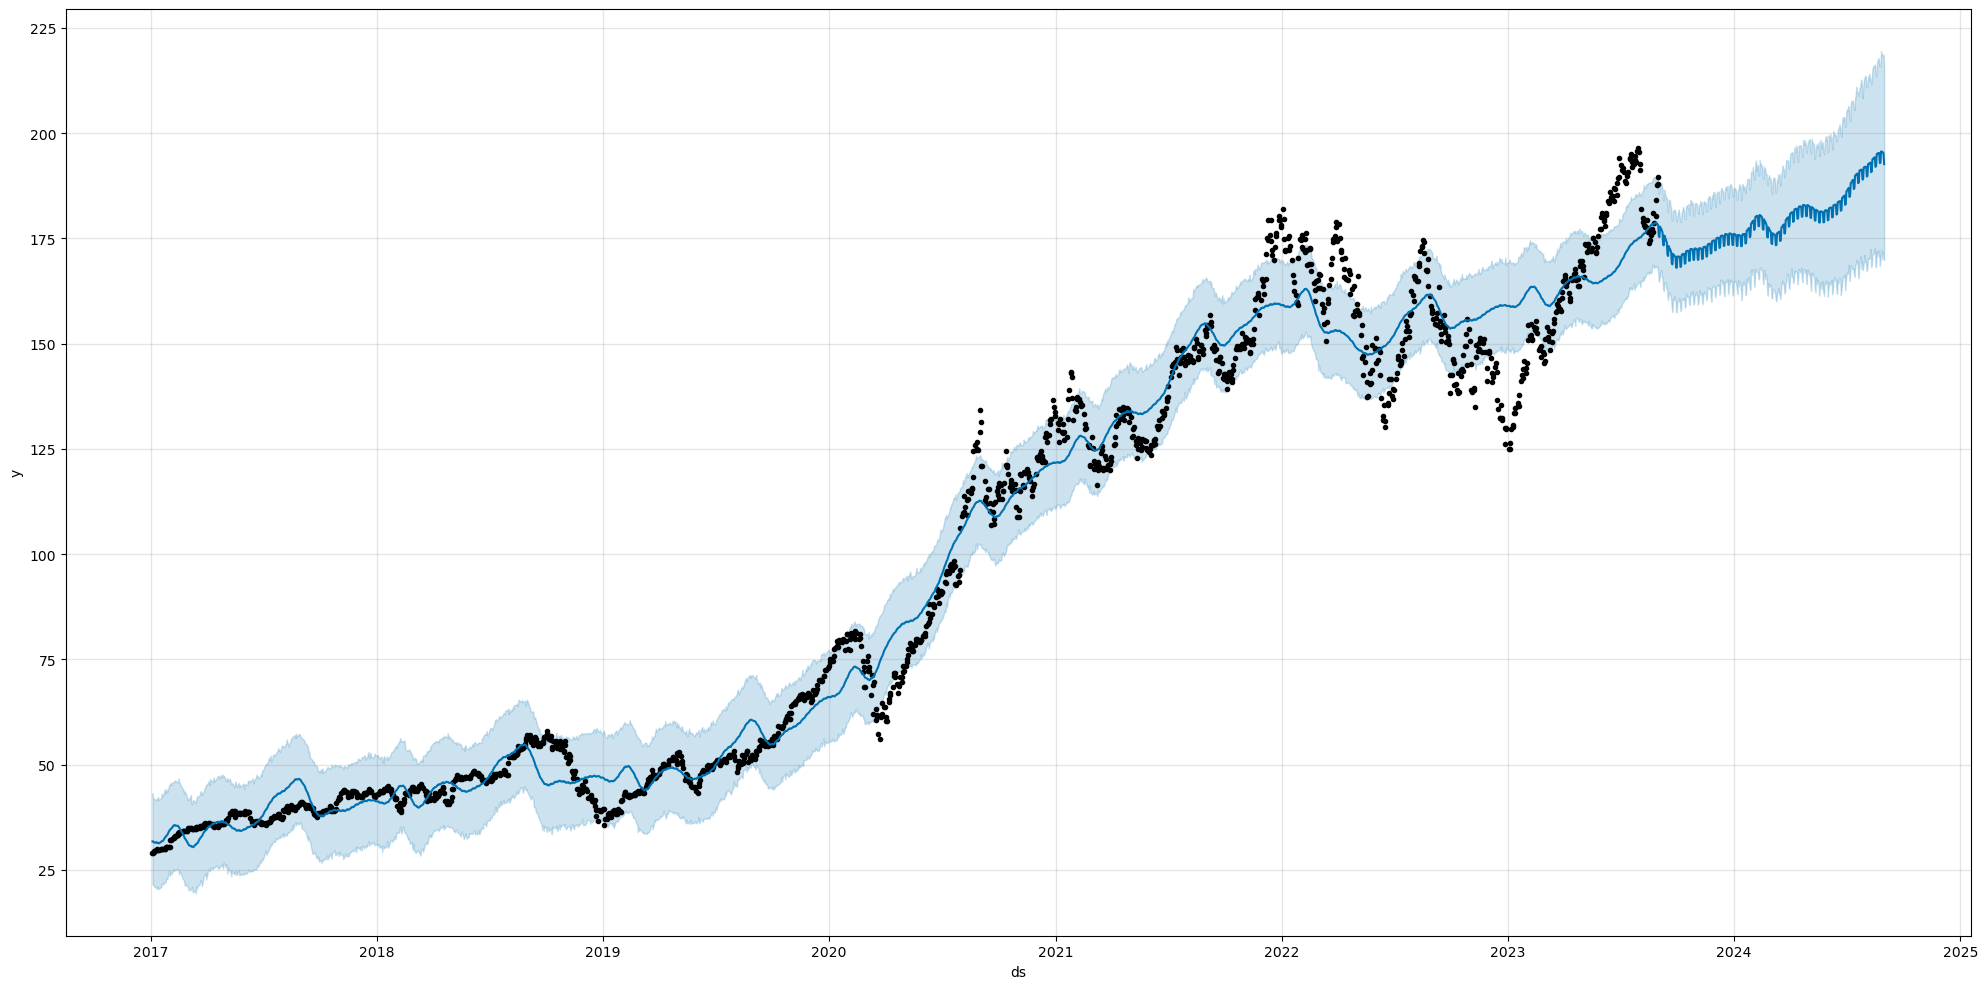

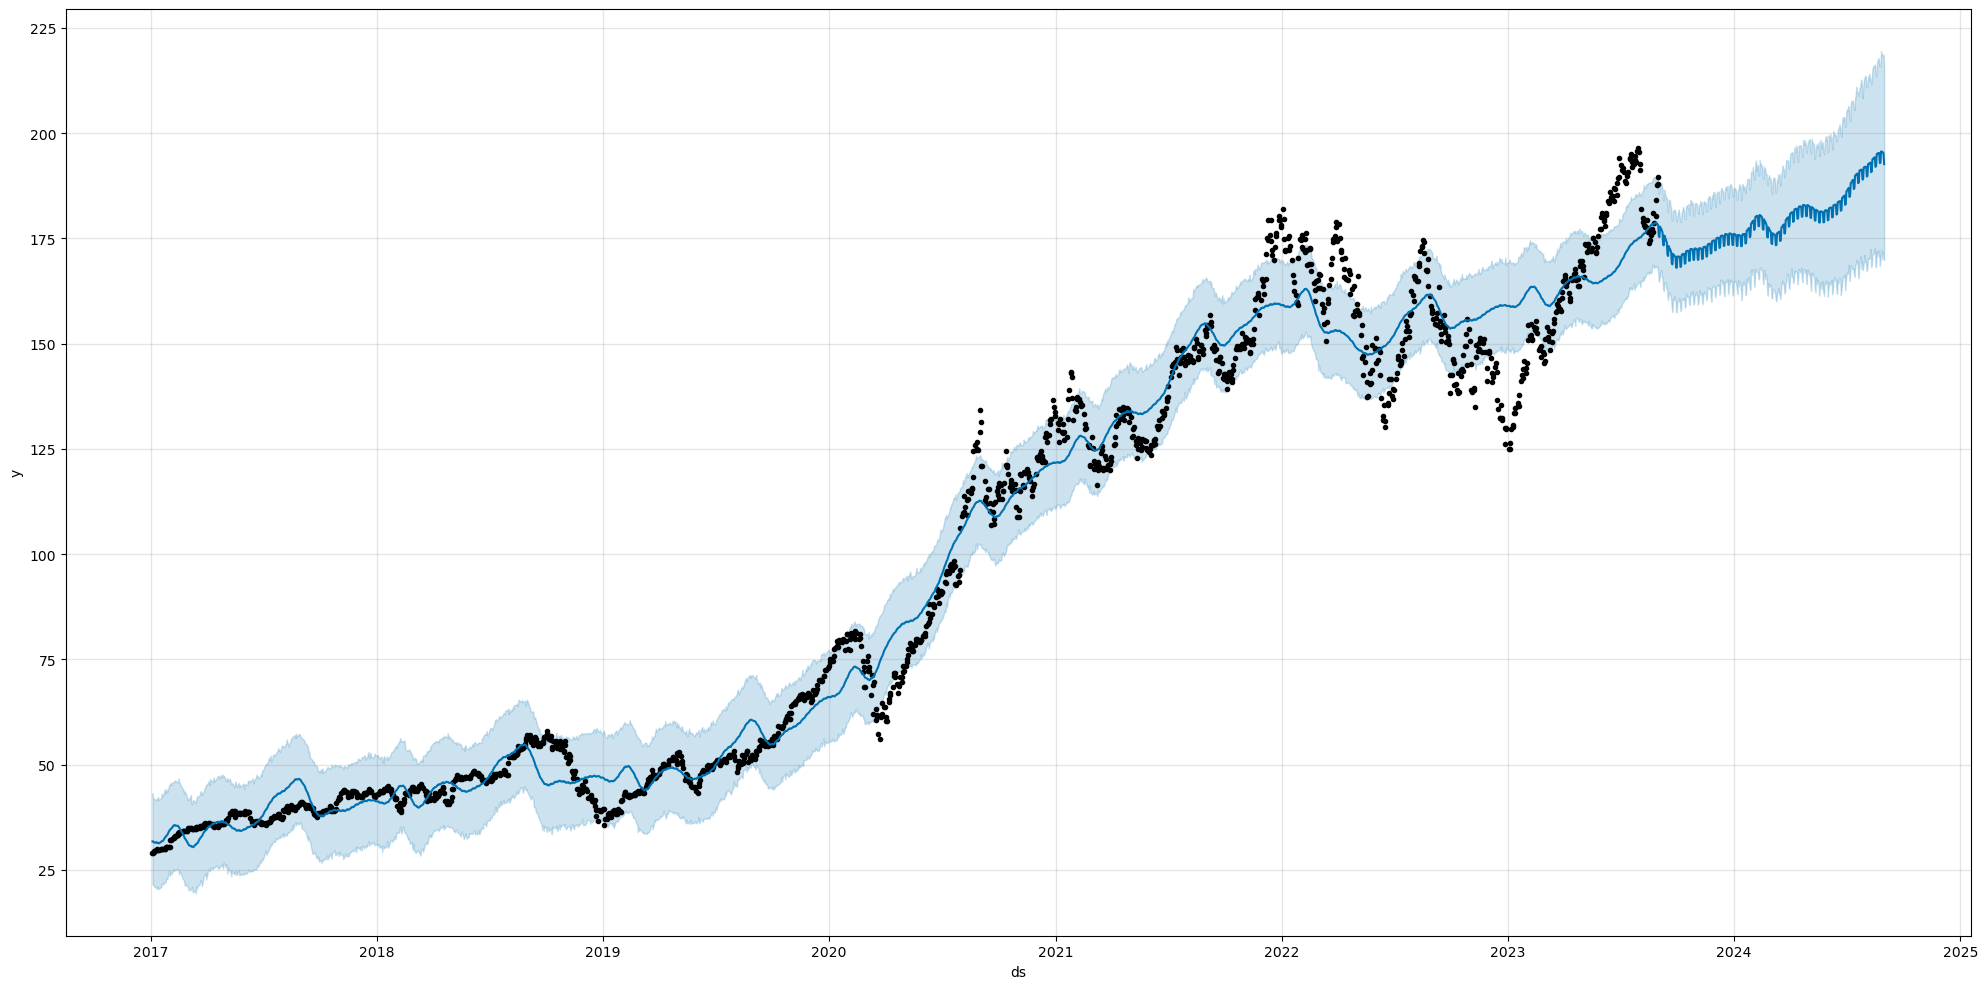

In [8]:
from prophet.plot import plot
prophet.plot(forecast, figsize=(20,10))